# Análise Exploratória de Dados - CadÚnico (amostra dez/2018)

============================================================

Bases:

- base_amostra_pessoa_201812.csv  (~12.8M linhas)

- base_amostra_familia_201812.csv (~4.8M linhas)

In [66]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os

warnings.filterwarnings("ignore")

BASE_DIR = os.path.abspath('')
DATA_DIR = os.path.join(BASE_DIR, "base_amostra_cad_201812")

PESSOA_FILE  = os.path.join(DATA_DIR, "base_amostra_pessoa_201812.csv")
FAMILIA_FILE = os.path.join(DATA_DIR, "base_amostra_familia_201812.csv")

SEP      = ";"
ENCODING = "latin-1"
AMOSTRA  = 200_000   # linhas para análise exploratória

# ── cores ────────────────────────────────────────────────────────────────────
COR1, COR2 = "#2563EB", "#16A34A"


## 1. CARGA

In [67]:
print("\n=== 1. Carregando dados ===")
pessoa = pd.read_csv(
    PESSOA_FILE,
    sep=SEP, encoding=ENCODING,
    nrows=AMOSTRA,
    low_memory=False
)
familia = pd.read_csv(
    FAMILIA_FILE,
    sep=SEP, encoding=ENCODING,
    nrows=AMOSTRA,
    low_memory=False
)
print(f"  pessoa : {pessoa.shape}")
print(f"  familia: {familia.shape}")


=== 1. Carregando dados ===
  pessoa : (200000, 35)
  familia: (200000, 31)


## 2. VISÃO GERAL

In [68]:
print("\n=== 2. Visão geral ===")
for nome, df in [("PESSOA", pessoa), ("FAMÍLIA", familia)]:
    print(f"\n--- {nome} ---")
    print(f"  Linhas: {len(df):,}  |  Colunas: {len(df.columns)}")
    miss = df.isnull().mean().sort_values(ascending=False)
    miss_cols = miss[miss > 0]
    print(f"  Colunas com missing: {len(miss_cols)}")
    if len(miss_cols):
        print(miss_cols.head(8).to_string())


=== 2. Visão geral ===

--- PESSOA ---
  Linhas: 200,000  |  Colunas: 35
  Colunas com missing: 23
cod_agricultura_trab_memb        0.780780
cod_principal_trab_memb          0.774225
val_renda_bruta_12_meses_memb    0.761070
qtd_meses_12_meses_memb          0.761070
cod_ano_serie_frequenta_memb     0.726500
cod_escola_local_memb            0.660730
cod_curso_frequenta_memb         0.658140
cod_afastado_trab_memb           0.556090

--- FAMÍLIA ---
  Linhas: 200,000  |  Colunas: 31
  Colunas com missing: 20
nom_centro_assist_fam            0.688470
cod_centro_assist_fam            0.688470
nom_estab_assist_saude_fam       0.527525
cod_eas_fam                      0.527525
cod_escoa_sanitario_domic_fam    0.125445
qtd_comodos_domic_fam            0.059885
qtd_comodos_dormitorio_fam       0.059655
cod_material_piso_fam            0.059535


## 3. ANÁLISE DE MISSINGNESS


=== 3. Missing values ===


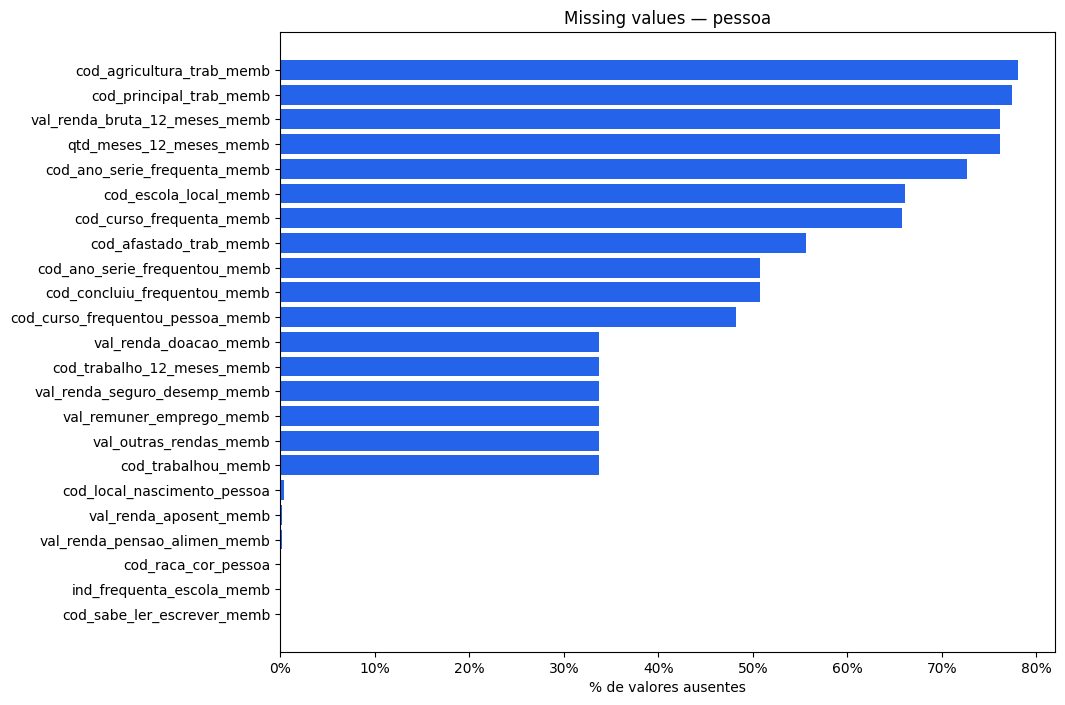

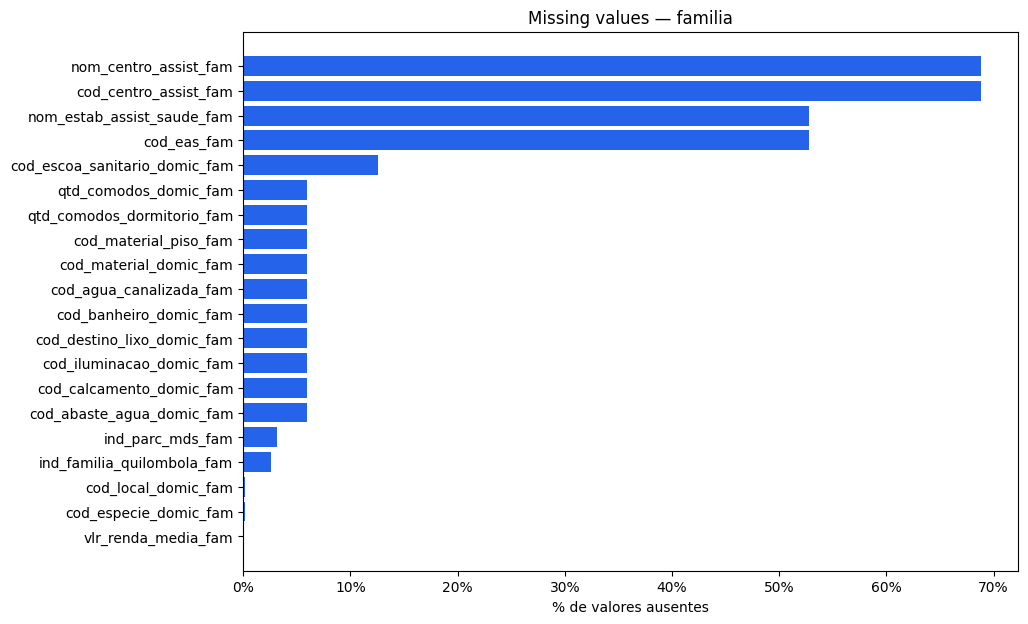

In [69]:
print("\n=== 3. Missing values ===")
for nome, df in [("pessoa", pessoa), ("familia", familia)]:
    miss = df.isnull().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    if miss.empty:
        print(f"  {nome}: sem missing values")
        continue

    fig, ax = plt.subplots(figsize=(10, max(4, len(miss) * 0.35)))
    ax.barh(miss.index[::-1], miss.values[::-1] * 100, color=COR1)
    ax.set_xlabel("% de valores ausentes")
    ax.set_title(f"Missing values — {nome}")
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    plt.show()

## 4. DISTRIBUIÇÃO DE VARIÁVEIS — PESSOA

In [70]:
print("\n=== 4. Distribuições — Pessoa ===")


=== 4. Distribuições — Pessoa ===


### 4a. Sexo

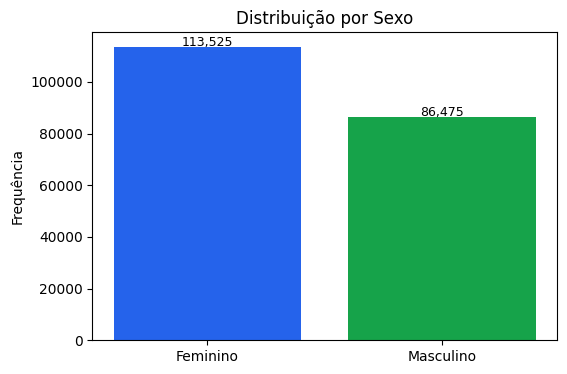

In [71]:
sexo_map = {1: "Masculino", 2: "Feminino"}
sexo = pessoa["cod_sexo_pessoa"].map(sexo_map).value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(sexo.index, sexo.values, color=[COR1, COR2])
ax.set_title("Distribuição por Sexo")
ax.set_ylabel("Frequência")
for i, v in enumerate(sexo.values):
    ax.text(i, v + 500, f"{v:,}", ha="center", fontsize=9)
plt.show()

### 4b. Pirâmide etária

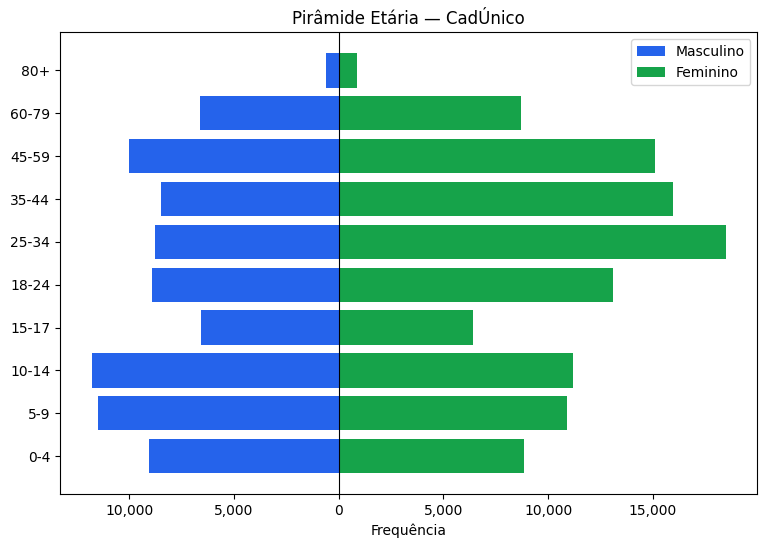

In [72]:
pessoa["faixa_etaria"] = pd.cut(
    pessoa["idade"],
    bins=[0, 4, 9, 14, 17, 24, 34, 44, 59, 79, 999],
    labels=["0-4","5-9","10-14","15-17","18-24","25-34","35-44","45-59","60-79","80+"],
    right=True
)

piramide = pessoa.groupby(["faixa_etaria", "cod_sexo_pessoa"], observed=True).size().unstack(fill_value=0)
piramide.columns = ["Masculino", "Feminino"]

fig, ax = plt.subplots(figsize=(9, 6))
y = range(len(piramide))
ax.barh(list(y), -piramide["Masculino"], color=COR1, label="Masculino")
ax.barh(list(y), piramide["Feminino"],  color=COR2, label="Feminino")
ax.set_yticks(list(y))
ax.set_yticklabels(piramide.index.tolist())
ax.set_xlabel("Frequência")
ax.set_title("Pirâmide Etária — CadÚnico")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{abs(int(x)):,}"))
ax.legend()
ax.axvline(0, color="black", linewidth=0.8)
plt.show()

### 4c. Raça/Cor

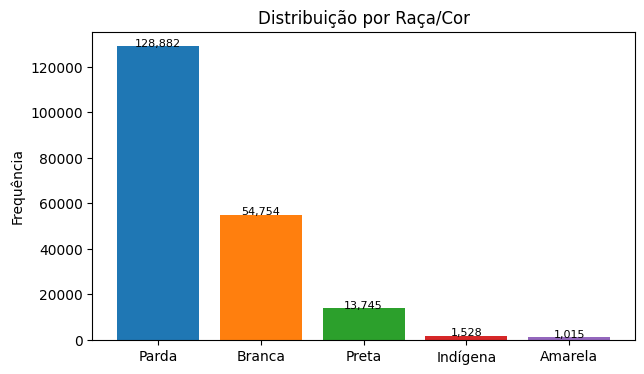

In [73]:
raca_map = {1: "Branca", 2: "Preta", 3: "Amarela", 4: "Parda", 5: "Indígena"}
raca = pessoa["cod_raca_cor_pessoa"].map(raca_map).value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(raca.index, raca.values, color=plt.cm.tab10.colors[:len(raca)])
ax.set_title("Distribuição por Raça/Cor")
ax.set_ylabel("Frequência")
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 200, f"{h:,}", ha="center", fontsize=8)
plt.show()

### 4d. Escolaridade (último curso frequentado)

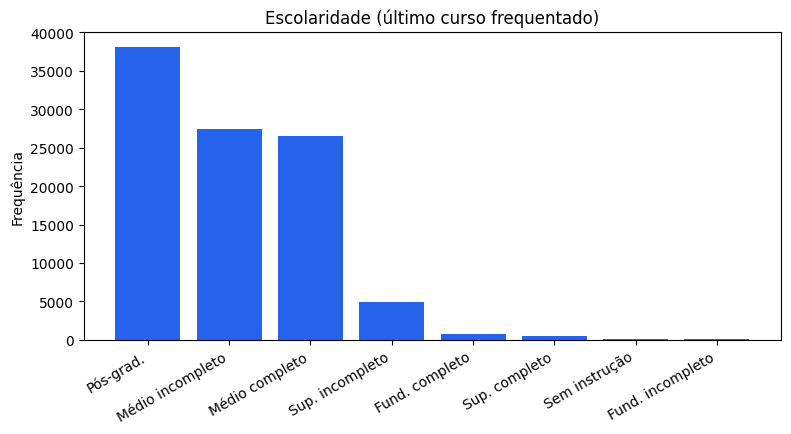

In [74]:
esc_map = {
    1: "Sem instrução", 2: "Fund. incompleto", 3: "Fund. completo",
    4: "Médio incompleto", 5: "Médio completo", 6: "Sup. incompleto",
    7: "Sup. completo", 8: "Pós-grad."
}
esc = pessoa["cod_curso_frequentou_pessoa_memb"].map(esc_map).value_counts()
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(esc.index, esc.values, color=COR1)
ax.set_title("Escolaridade (último curso frequentado)")
ax.set_ylabel("Frequência")
plt.xticks(rotation=30, ha="right")
plt.show()

### 4e. Deficiência

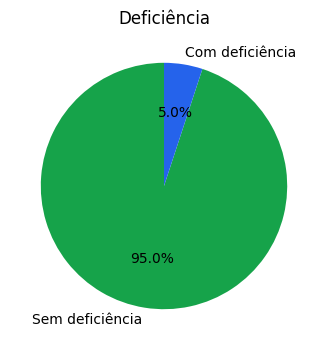

In [75]:
def_map = {1: "Com deficiência", 2: "Sem deficiência"}
defic = pessoa["cod_deficiencia_memb"].map(def_map).value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
ax.pie(defic.values, labels=defic.index, autopct="%1.1f%%",
       colors=[COR2, COR1], startangle=90)
ax.set_title("Deficiência")
plt.show()

### 4f. Renda de emprego (sem zeros)

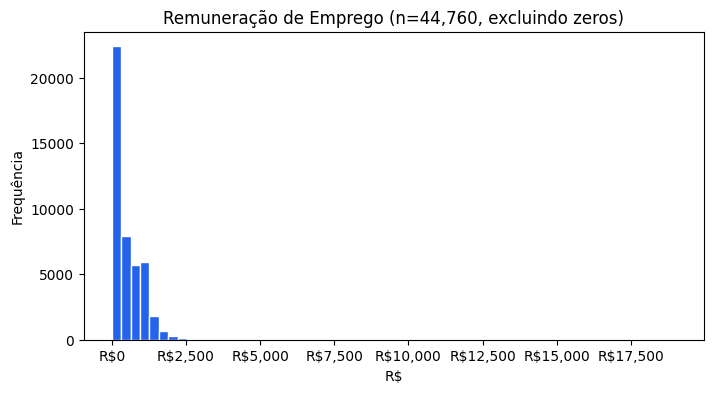


  Estatísticas — val_remuner_emprego_memb (positivos):
count    R$ 44,760.00
mean        R$ 518.35
std         R$ 527.58
min           R$ 1.00
25%         R$ 150.00
50%         R$ 315.00
75%         R$ 889.00
max      R$ 19,000.00


In [76]:
renda = pessoa["val_remuner_emprego_memb"]
renda_pos = renda[renda > 0].dropna()
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(renda_pos, bins=60, color=COR1, edgecolor="white")
ax.set_title(f"Remuneração de Emprego (n={len(renda_pos):,}, excluindo zeros)")
ax.set_xlabel("R$")
ax.set_ylabel("Frequência")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))
plt.show()

print(f"\n  Estatísticas — val_remuner_emprego_memb (positivos):")
print(renda_pos.describe().apply(lambda x: f"R$ {x:,.2f}").to_string())

## 5. ANÁLISE DE VARIÁVEIS — FAMÍLIA

In [77]:
print("\n=== 5. Distribuições — Família ===")


=== 5. Distribuições — Família ===


### 5a. Renda média familiar

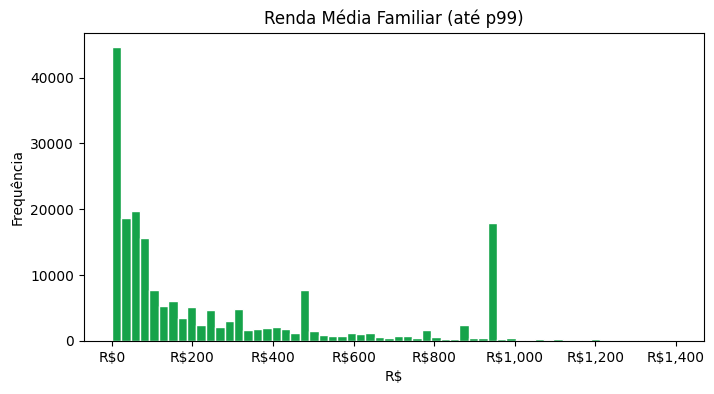


  Estatísticas — vlr_renda_media_fam:
count    R$ 199,986.00
mean         R$ 272.62
std          R$ 353.07
min            R$ 0.00
25%           R$ 28.00
50%          R$ 100.00
75%          R$ 412.00
max        R$ 2,862.00


In [78]:
renda_fam = familia["vlr_renda_media_fam"].dropna()
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(renda_fam[renda_fam <= renda_fam.quantile(0.99)], bins=60,
        color=COR2, edgecolor="white")
ax.set_title("Renda Média Familiar (até p99)")
ax.set_xlabel("R$")
ax.set_ylabel("Frequência")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))
plt.show()

print(f"\n  Estatísticas — vlr_renda_media_fam:")
print(renda_fam.describe().apply(lambda x: f"R$ {x:,.2f}").to_string())

### 5b. Tamanho da família

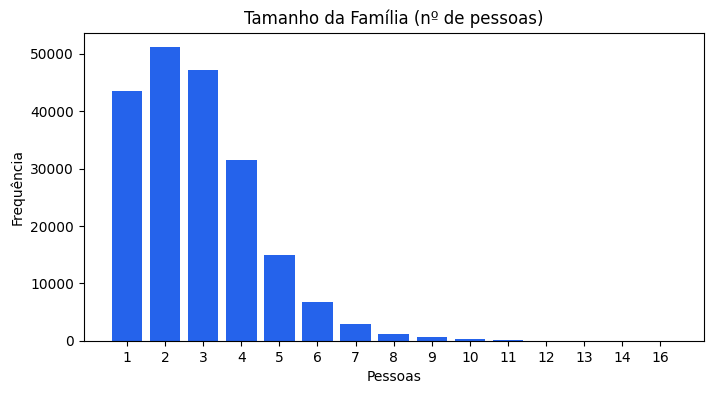


  Tamanho médio da família: 2.84 pessoas


In [79]:
tam = familia["qtde_pessoas"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(tam.index.astype(str), tam.values, color=COR1)
ax.set_title("Tamanho da Família (nº de pessoas)")
ax.set_xlabel("Pessoas")
ax.set_ylabel("Frequência")
plt.show()

print(f"\n  Tamanho médio da família: {familia['qtde_pessoas'].mean():.2f} pessoas")

### 5c. Benefício Bolsa Família

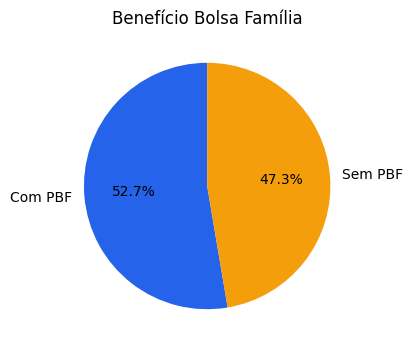

In [80]:
pbf = familia["marc_pbf"].value_counts()
pbf.index = pbf.index.map({0: "Sem PBF", 1: "Com PBF"})
fig, ax = plt.subplots(figsize=(5, 4))
ax.pie(pbf.values, labels=pbf.index, autopct="%1.1f%%",
       colors=[COR1, "#F59E0B"], startangle=90)
ax.set_title("Benefício Bolsa Família")
plt.show()

### 5d. Abastecimento de água

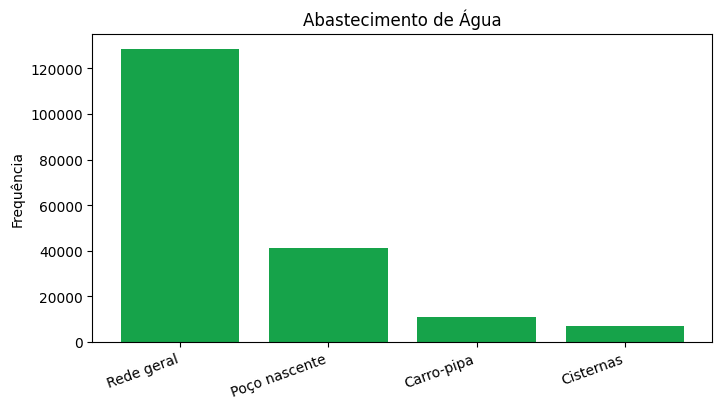

In [81]:
agua_map = {
    1: "Rede geral", 2: "Poço nascente", 3: "Cisternas",
    4: "Carro-pipa", 5: "Rio/lago", 6: "Outra"
}
agua = familia["cod_abaste_agua_domic_fam"].map(agua_map).value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(agua.index, agua.values, color=COR2)
ax.set_title("Abastecimento de Água")
ax.set_ylabel("Frequência")
plt.xticks(rotation=20, ha="right")
plt.show()

### 5e. Destino do lixo

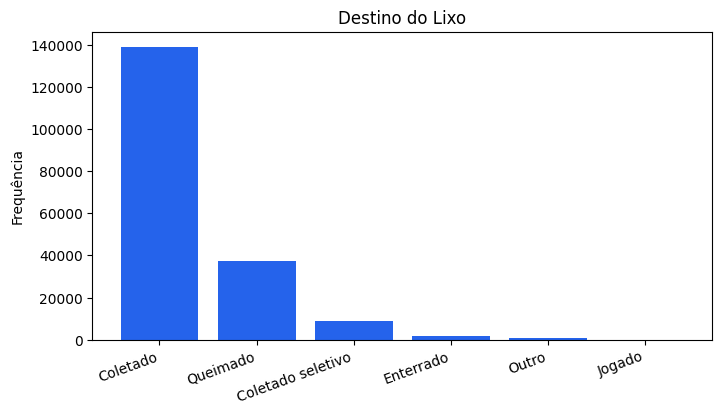

In [82]:
lixo_map = {
    1: "Coletado", 2: "Coletado seletivo", 3: "Queimado",
    4: "Enterrado", 5: "Jogado", 6: "Outro"
}
lixo = familia["cod_destino_lixo_domic_fam"].map(lixo_map).value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(lixo.index, lixo.values, color=COR1)
ax.set_title("Destino do Lixo")
ax.set_ylabel("Frequência")
plt.xticks(rotation=20, ha="right")
plt.show()

## 6. CORRELAÇÃO — FAMÍLIA (numéricas)


=== 6. Correlação — Família ===


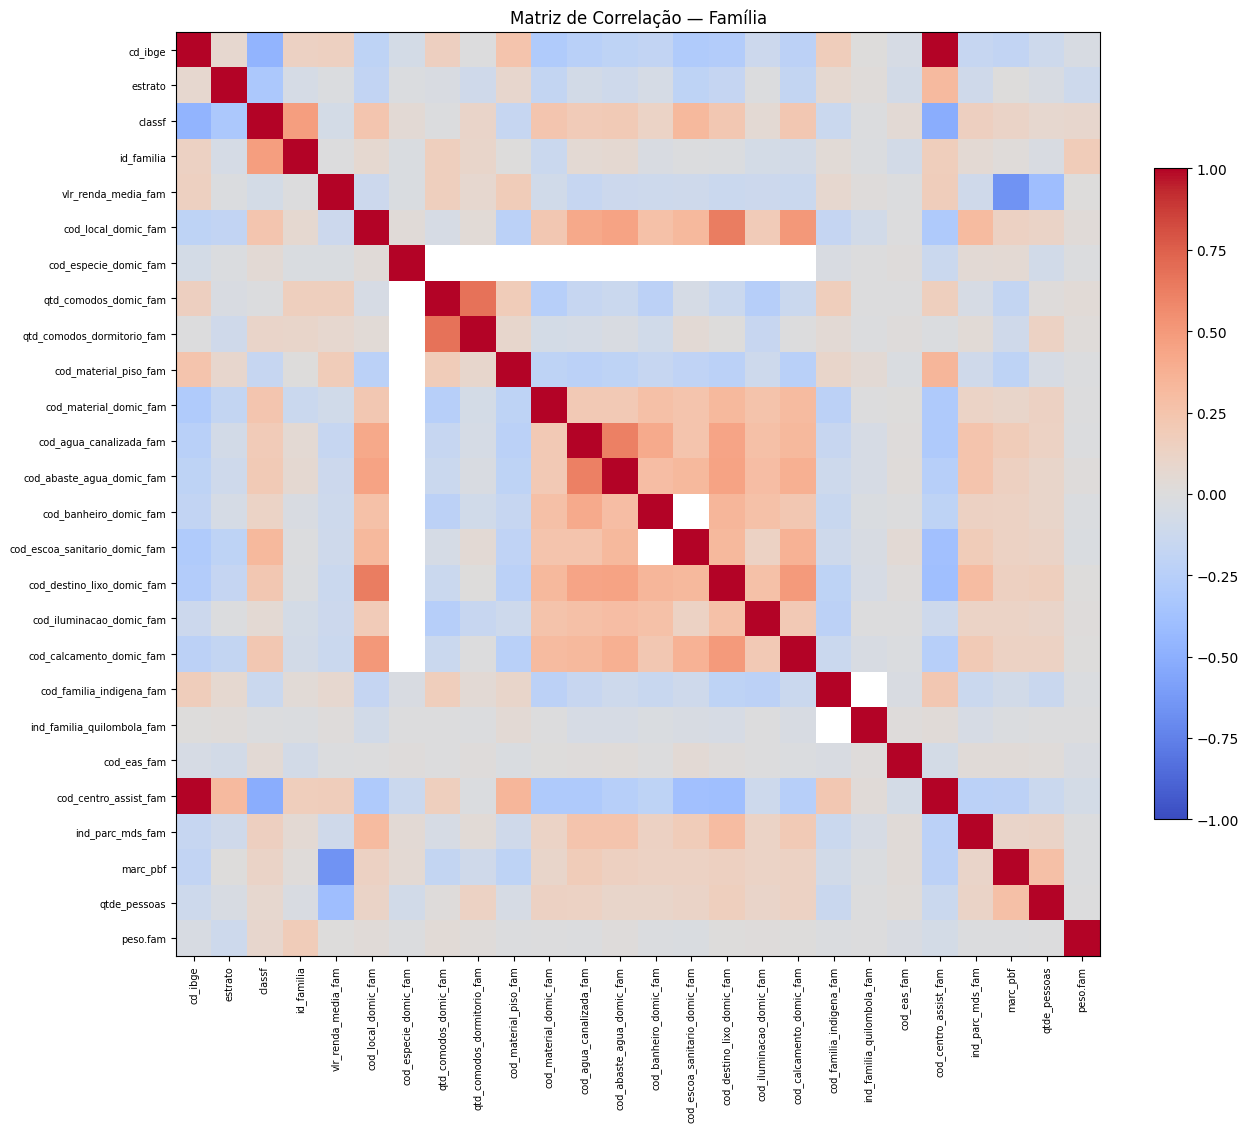

In [83]:
print("\n=== 6. Correlação — Família ===")
num_cols_fam = familia.select_dtypes(include=np.number).columns.tolist()
corr = familia[num_cols_fam].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticklabels(corr.columns, fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.03)
ax.set_title("Matriz de Correlação — Família")
plt.show()

## 7. RESUMO FINAL

In [84]:
print("\n=== RESUMO FINAL ===")
print(f"  Amostra utilizada: {AMOSTRA:,} linhas por base")

print("\nConcluído.")


=== RESUMO FINAL ===
  Amostra utilizada: 200,000 linhas por base

Concluído.
